<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/Hirusha/Garabage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# =============================================================================
# SE4050 Deep Learning Assignment - MobileNetV2 Implementation
# Team Member: Sumanaweera A D H R
# Model: MobileNetV2 for Waste Classification
# Dataset: Waste Classification Data (Organic vs Recyclable)
# =============================================================================

# Import  libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
from datetime import datetime

In [ ]:
!apt-get install p7zip-full


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:

import os

seven_z_path = '/content/drive/MyDrive/DATASET.7z'
extract_dir = '/content/DATASET/DATASET'

# Create extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract using 7z command
!7z x "{seven_z_path}" -o"{extract_dir}" -y
print(f"7z file extracted to: {extract_dir}")

# =============================================================================
# DATA PREPARATION AND LOADING
# =============================================================================
train_dir = os.path.join(extract_dir, 'TRAIN')
test_dir = os.path.join(extract_dir, 'TEST')

print("Training directory:", train_dir)
print("Test directory:", test_dir)

# Function to count images in 'organic(O)' and 'recyclable(R)' folders
def count_images(directory):
    organic_count = len(os.listdir(os.path.join(directory, 'O')))
    recyclable_count = len(os.listdir(os.path.join(directory, 'R')))
    return organic_count, recyclable_count

# Count and print the number of images
try:
    train_organic, train_recyclable = count_images(train_dir)
    test_organic, test_recyclable = count_images(test_dir)

    print(f"\nTraining Data: {train_organic} organic, {train_recyclable} recyclable")
    print(f"Test Data: {test_organic} organic, {test_recyclable} recyclable")
    print(f"Total Images: {train_organic + train_recyclable + test_organic + test_recyclable}")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check your dataset paths and folder structure!")



7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/                                 1 file, 216000968 bytes (206 MiB)

Extracting archive: /content/drive/MyDrive/DATASET.7z
--
Path = /content/drive/MyDrive/DATASET.7z
Type = 7z
Physical Size = 216000968
Headers Size = 305148
Method = LZMA:23
Solid = +
Blocks = 1

  0%      1%      2% 421 - DATASET/TEST/O/O_12988.jpg                                       3% 672 - DATASET/TEST/O/O_13239.jpg                                       5% 794 - DATASET/TEST/O/O_13361.jpg     

In [ ]:
# =============================================================================
#  DATA PREPROCESSING AND AUGMENTATION
# =============================================================================

# Image parameters for MobileNetV2
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

# Data Augmentation for Training
# Why augmentation? Prevents overfitting and improves model generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0,1]
    rotation_range=30,           # Random rotation up to 30 degrees
    width_shift_range=0.2,       # Random horizontal shift
    height_shift_range=0.2,      # Random vertical shift
    horizontal_flip=True,        # Random horizontal flip
    zoom_range=0.2,              # Random zoom
    shear_range=0.2,             # Random shear
    brightness_range=[0.8, 1.2], # Random brightness adjustment
    fill_mode='nearest'          # Fill missing pixels with nearest
)

# Only rescaling for validation/test data (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # For multi-class classification
    shuffle=True,              # Shuffle training data
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,             # Don't shuffle test data for consistent evaluation
    seed=42
)

# Get class indices and labels
class_names = list(train_generator.class_indices.keys())
print(f" Class names: {class_names}")
print(f" Class indices: {train_generator.class_indices}")

Found 22564 images belonging to 2 classes.
Found 2514 images belonging to 2 classes.
 Class names: ['O', 'R']
 Class indices: {'O': 0, 'R': 1}


In [ ]:

# =============================================================================
# MOBILENETV2 MODEL ARCHITECTURE
# =============================================================================


# Load pre-trained MobileNetV2 without top layers
base_model = MobileNetV2(
    weights='imagenet',           # Use pre-trained ImageNet weights
    include_top=False,            # Exclude classification head
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model layers initially
base_model.trainable = False

print(f" Base Model: MobileNetV2")
print(f" Base model layers frozen: {len([layer for layer in base_model.layers if not layer.trainable])} layers")

# Add custom classification head
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Use base model as feature extractor
x = base_model(inputs, training=False)

# Global Average Pooling instead of Flatten (reduces parameters, prevents overfitting)
x = GlobalAveragePooling2D()(x)

# Add Batch Normalization for stability
x = BatchNormalization()(x)

# Add Dense layers with Dropout for regularization
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)  # Dropout to prevent overfitting

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

# Output layer
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
model = Model(inputs, outputs)

print(" Model architecture created!")

# Display model summary
model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Base Model: MobileNetV2
 Base model layers frozen: 154 layers
 Model architecture created!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,458 (9.29 MB)

 Trainable params: 174,914 (683.26 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# =============================================================================
# MODEL COMPILATION
# =============================================================================

model.compile(
    optimizer=Adam(learning_rate=0.001),  # Adam optimizer with initial learning rate
    loss='categorical_crossentropy',      # Appropriate for multi-class classification
    metrics=['accuracy', 'precision', 'recall']  # Multiple metrics for evaluation
)

print(" Model compiled successfully!")

 Model compiled successfully!


In [ ]:
# =============================================================================
# CALLBACKS SETUP
# =============================================================================

# Define callbacks for better training
callbacks = [
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,           # Reduce LR by 80%
        patience=3,           # Wait for 3 epochs with no improvement
        min_lr=1e-7,          # Minimum learning rate
        verbose=1
    ),

    # Stop training if no improvement for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,  # Restore weights from best epoch
        verbose=1
    ),

    # Save best model during training
    ModelCheckpoint(
        'best_mobilenetv2_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print(" Callbacks configured!")

 Callbacks configured!


In [ ]:
# =============================================================================
# INITIAL TRAINING (FEATURE EXTRACTION)
# =============================================================================

print("\n  Initial Training - Feature Extraction Phase")
print(" Training only the custom head, base model frozen")

# Calculate steps per epoch
train_steps = train_generator.samples // BATCH_SIZE
val_steps = test_generator.samples // BATCH_SIZE

print(f" Training steps per epoch: {train_steps}")
print(f" Validation steps per epoch: {val_steps}")

# Initial training with frozen base model
print(" Starting initial training.")
history = model.fit(
    train_generator,
    epochs=10,                    # Initial training epochs
    steps_per_epoch=train_steps,
    validation_data=test_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

print(" Initial training completed!")



 STEP 6: Initial Training - Feature Extraction Phase
 Training only the custom head, base model frozen
 Training steps per epoch: 705
 Validation steps per epoch: 78
 Starting initial training.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.8808 - loss: 0.3009 - precision: 0.8808 - recall: 0.8808
Epoch 1: val_accuracy improved from -inf to 0.89944, saving model to best_mobilenetv2_model.h5


705/705 ━━━━━━━━━━━━━━━━━━━━ 341s 457ms/step - accuracy: 0.8808 - loss: 0.3008 - precision: 0.8808 - recall: 0.8808 - val_accuracy: 0.8994 - val_loss: 0.2450 - val_precision: 0.8994 - val_recall: 0.8994 - learning_rate: 0.0010
Epoch 2/10
  1/705 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8125 - loss: 0.3585 - precision: 0.8125 - recall: 0.8125

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.89944 to 0.90144, saving model to best_mobilenetv2_model.h5


705/705 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8125 - loss: 0.3585 - precision: 0.8125 - recall: 0.8125 - val_accuracy: 0.9014 - val_loss: 0.2434 - val_precision: 0.9014 - val_recall: 0.9014 - learning_rate: 0.0010
Epoch 3/10
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9273 - loss: 0.1942 - precision: 0.9273 - recall: 0.9273
Epoch 3: val_accuracy did not improve from 0.90144
705/705 ━━━━━━━━━━━━━━━━━━━━ 298s 423ms/step - accuracy: 0.9273 - loss: 0.1942 - precision: 0.9273 - recall: 0.9273 - val_accuracy: 0.8942 - val_loss: 0.2656 - val_precision: 0.8942 - val_recall: 0.8942 - learning_rate: 0.0010
Epoch 4/10
  1/705 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.8750 - loss: 0.1989 - precision: 0.8750 - recall: 0.8750
Epoch 4: val_accuracy did not improve from 0.90144
705/705 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8750 - loss: 0.1989 - precision: 0.8750 - recall: 0.8750 - val_accuracy: 0.8946 - val_loss: 0.2653 - val_precision: 0.8946 - val_recall: 0.8946

In [ ]:
# =============================================================================
# FINE-TUNING
# =============================================================================

# Unfreeze some layers of base model for fine-tuning
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f" Unfrozen layers: {len([layer for layer in base_model.layers if layer.trainable])}")

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.0001/10),  # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print(" Starting fine-tuning...")

# Continue training with fine-tuning
fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    steps_per_epoch=train_steps,
    validation_data=test_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

print(" Fine-tuning completed!")



 Unfrozen layers: 54
 Starting fine-tuning...
Epoch 7/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9086 - loss: 0.2353 - precision: 0.9086 - recall: 0.9086
Epoch 7: val_accuracy did not improve from 0.90144
705/705 ━━━━━━━━━━━━━━━━━━━━ 347s 458ms/step - accuracy: 0.9086 - loss: 0.2353 - precision: 0.9086 - recall: 0.9086 - val_accuracy: 0.8678 - val_loss: 0.2978 - val_precision: 0.8678 - val_recall: 0.8678 - learning_rate: 1.0000e-05
Epoch 8/20
  1/705 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.9688 - loss: 0.1208 - precision: 0.9688 - recall: 0.9688
Epoch 8: val_accuracy did not improve from 0.90144
705/705 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9688 - loss: 0.1208 - precision: 0.9688 - recall: 0.9688 - val_accuracy: 0.8678 - val_loss: 0.2981 - val_precision: 0.8678 - val_recall: 0.8678 - learning_rate: 1.0000e-05
Epoch 9/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9260 - loss: 0.1927 - precision: 0.9260 - recall: 0.9260
Epoch 9: val_accura

In [ ]:
# =============================================================================
#  MODEL EVALUATION
# =============================================================================

# Load the best saved model
best_model = keras.models.load_model('best_mobilenetv2_model.h5')

# Evaluate on test data
print(" Evaluating model on test data...")
test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(test_generator)
print(f" Test Accuracy: {test_accuracy:.4f}")
print(f" Test Precision: {test_precision:.4f}")
print(f" Test Recall: {test_recall:.4f}")


 Evaluating model on test data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.9323 - loss: 0.1680 - precision_2: 0.9323 - recall_2: 0.9323
 Test Accuracy: 0.9010
 Test Precision: 0.9010
 Test Recall: 0.9010


In [7]:

# =============================================================================
# PREDICTIONS AND METRICS
# =============================================================================

# Get true labels and predictions
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# Classification Report
print("\n Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Confusion Matrix
print(" Confusion Matrix:")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


NameError: name 'test_generator' is not defined

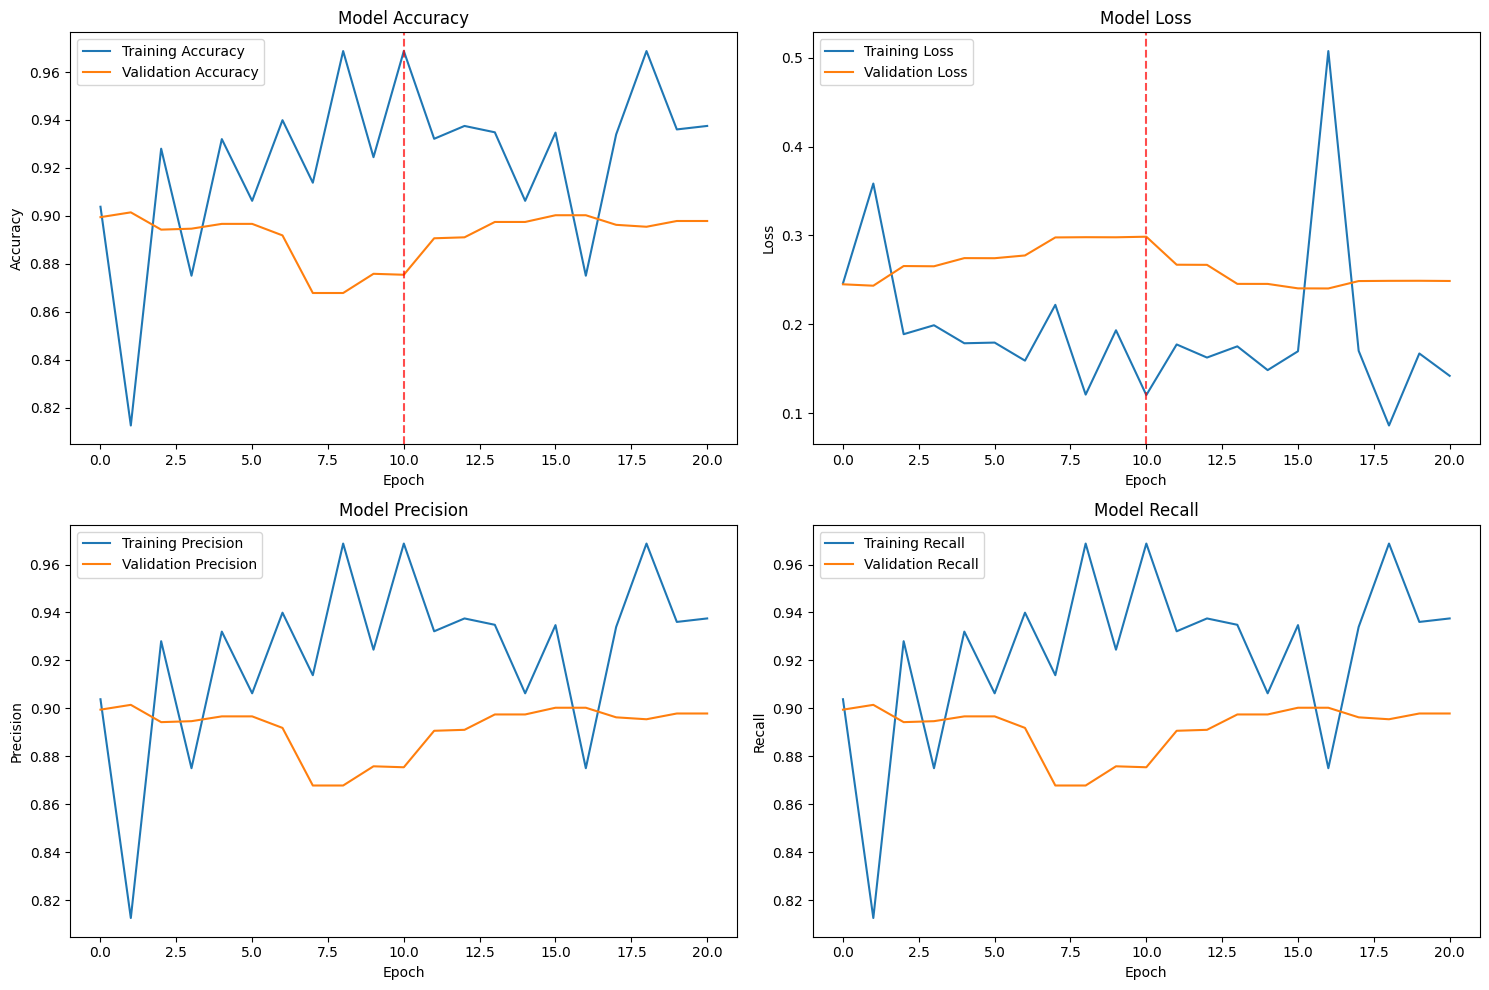

In [ ]:
# =============================================================================
# VISUALIZATION
# =============================================================================

# Combine history from both training phases
def combine_histories(initial_history, fine_history):
    combined_history = {}
    for key in initial_history.history.keys():
        combined_history[key] = initial_history.history[key] + fine_history.history[key]
    return combined_history

combined_history = combine_histories(history, history_fine)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(combined_history['accuracy'], label='Training Accuracy')
axes[0, 0].plot(combined_history['val_accuracy'], label='Validation Accuracy')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].axvline(x=10, color='r', linestyle='--', alpha=0.7, label='Fine-tuning Start')

# Loss
axes[0, 1].plot(combined_history['loss'], label='Training Loss')
axes[0, 1].plot(combined_history['val_loss'], label='Validation Loss')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].axvline(x=10, color='r', linestyle='--', alpha=0.7, label='Fine-tuning Start')

# Precision
axes[1, 0].plot(combined_history['precision'], label='Training Precision')
axes[1, 0].plot(combined_history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

# Recall
axes[1, 1].plot(combined_history['recall'], label='Training Recall')
axes[1, 1].plot(combined_history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# MODEL SAVING AND SUMMARY
# =============================================================================

# Save the final model
model.save('final_mobilenetv2_waste_classifier.h5')
print(" Final model saved as 'final_mobilenetv2_waste_classifier.h5'")

# Model summary
print("\n" + "="*50)
print(" MOBILENETV2 IMPLEMENTATION SUMMARY")
print("="*50)
print(f" Dataset: Waste Classification (Organic vs Recyclable)")
print(f" Input Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f" Classes: {class_names}")
print(f" Test Accuracy: {test_accuracy:.4f}")
print(f" Test Precision: {test_precision:.4f}")
print(f" Test Recall: {test_recall:.4f}")
print(f" Model Size: {os.path.getsize('final_mobilenetv2_waste_classifier.h5') / (1024*1024):.2f} MB")
print("="*50)

print("\n MobileNetV2 Implementation Completed Successfully!")

 Final model saved as 'final_mobilenetv2_waste_classifier.h5'

 MOBILENETV2 IMPLEMENTATION SUMMARY
 Dataset: Waste Classification (Organic vs Recyclable)
 Input Size: 224x224
 Classes: ['O', 'R']
 Test Accuracy: 0.9010
 Test Precision: 0.9010
 Test Recall: 0.9010
 Model Size: 25.24 MB

 MobileNetV2 Implementation Completed Successfully!


In [6]:

from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/final_mobilenetv2_waste_classifier.h5")


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/DATASET/DATASET/TEST/O/O_12619.jpg"  # change to any test image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
classes = ['ORGANIC', 'RECYCLE']
print("Predicted Class:", classes[np.argmax(pred)])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Class: ORGANIC
